# Initial state prior shapes

`phi_init` is a Dirichlet over the `n_states - 2*response_width` free states, padded with
`response_width` zeros on each side. For a Dirichlet, `E[p_i] = conc_i / sum(conc)`, so the
**shape** of the concentration vector is the prior mean shape and its **magnitude** is how
tightly draws cluster around that shape.

This notebook compares three concentration choices:

1. **Current** - `conc ~ Beta(0.5, 0.5) + 0.01`, sampled independently per state
2. **Proposed Markov** - fixed, Gaussian bump in the centre
3. **Proposed Quantum** - fixed, bumps at both boundaries, trough in the centre

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_STATES = 51
RESPONSE_WIDTH = 15
S = N_STATES - 2 * RESPONSE_WIDTH

PHI_CONC_BASE = 1.0
PHI_CONC_AMP = 4.0

rng = np.random.default_rng(0)
states = np.arange(S) - (S - 1) / 2
print(f"n_states={N_STATES}, response_width={RESPONSE_WIDTH} -> {S} free states")

n_states=51, response_width=15 -> 21 free states


## The proposed concentration

This is the helper being proposed for `_get_initial_state`. Change `PHI_CONC_AMP` to make the
bump more or less pronounced, and `w` to make it wider or narrower.

In [2]:
def initial_state_concentration(n_free, model_type, base=PHI_CONC_BASE, amp=PHI_CONC_AMP):
    x = np.arange(n_free) - (n_free - 1) / 2
    w = n_free / 6
    if model_type == "Markov":
        shape = np.exp(-0.5 * (x / w) ** 2)
    elif model_type == "Quantum":
        e = (n_free - 1) / 2
        shape = np.exp(-0.5 * ((x - e) / w) ** 2) + np.exp(-0.5 * ((x + e) / w) ** 2)
    else:
        raise Exception(f"Please select one of {model_type}")
    return base + amp * shape


conc_markov = initial_state_concentration(S, "Markov")
conc_quantum = initial_state_concentration(S, "Quantum")

print("Markov  conc:", conc_markov.round(2))
print("Quantum conc:", conc_quantum.round(2))
print(f"\nsum(conc): Markov {conc_markov.sum():.1f}, Quantum {conc_quantum.sum():.1f}")
print("(higher sum = draws cluster more tightly around the mean shape)")

Markov  conc: [1.07 1.15 1.29 1.54 1.92 2.44 3.08 3.77 4.4  4.84 5.   4.84 4.4  3.77
 3.08 2.44 1.92 1.54 1.29 1.15 1.07]
Quantum conc: [5.   4.84 4.4  3.77 3.08 2.44 1.92 1.55 1.3  1.18 1.14 1.18 1.3  1.55
 1.92 2.44 3.08 3.77 4.4  4.84 5.  ]

sum(conc): Markov 56.0, Quantum 60.1
(higher sum = draws cluster more tightly around the mean shape)


## What the current code does

`conc = Beta(0.5, 0.5) + 0.01` is U-shaped, so each state independently draws a concentration
near 0.01 or near 1.01. Concentrations below 1 make the Dirichlet density diverge at the
simplex corners, which is the suspected cause of the high `phi_init` r_hat.

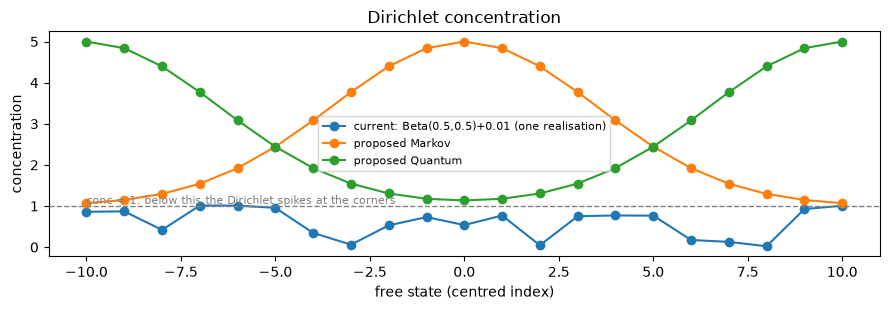

In [3]:
conc_current = rng.beta(0.5, 0.5, size=S) + 0.01

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(states, conc_current, "o-", label="current: Beta(0.5,0.5)+0.01 (one realisation)")
ax.plot(states, conc_markov, "o-", label="proposed Markov")
ax.plot(states, conc_quantum, "o-", label="proposed Quantum")
ax.axhline(1.0, ls="--", c="grey", lw=1)
ax.text(states[0], 1.05, "conc = 1: below this the Dirichlet spikes at the corners",
        fontsize=8, c="grey")
ax.set_xlabel("free state (centred index)")
ax.set_ylabel("concentration")
ax.set_title("Dirichlet concentration")
ax.legend(fontsize=8)
plt.tight_layout()

## Prior mean shape

`E[p_i] = conc_i / sum(conc)` - this is the shape being asked for: a centred bump for Markov,
mass at the two boundaries for Quantum.

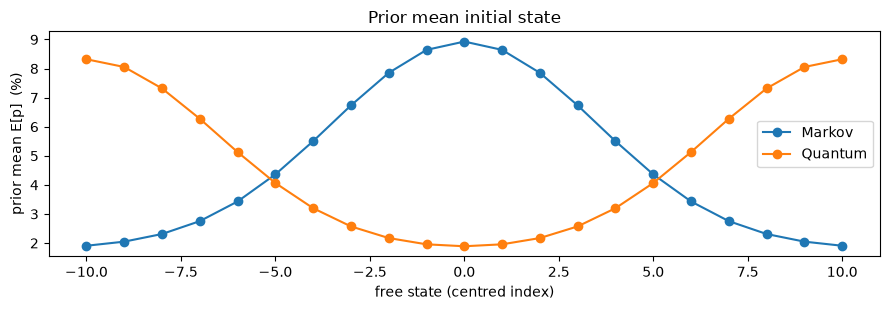

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(states, 100 * conc_markov / conc_markov.sum(), "o-", label="Markov")
ax.plot(states, 100 * conc_quantum / conc_quantum.sum(), "o-", label="Quantum")
ax.set_xlabel("free state (centred index)")
ax.set_ylabel("prior mean E[p]  (%)")
ax.set_title("Prior mean initial state")
ax.legend()
plt.tight_layout()

## Draws, not just the mean

The mean is smooth; individual draws are not. This is the modelling choice to make: whether the
prior says *"centred on average"* or *"each participant's initial state is itself a smooth bump"*.
Raise `base` and `amp` together to tighten the draws.

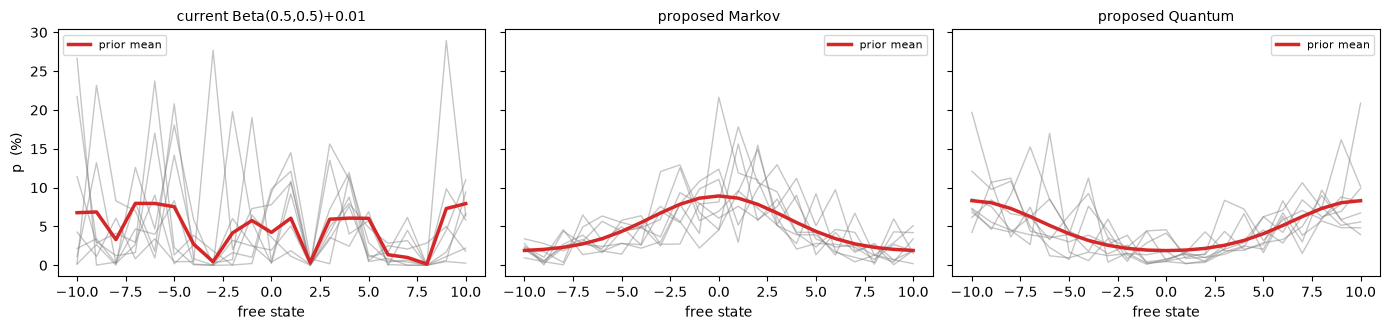

In [5]:
n_draws = 8
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)

for ax, (title, conc) in zip(
    axes,
    [("current Beta(0.5,0.5)+0.01", conc_current),
     ("proposed Markov", conc_markov),
     ("proposed Quantum", conc_quantum)],
):
    for d in rng.dirichlet(conc, n_draws):
        ax.plot(states, 100 * d, c="grey", alpha=0.45, lw=1)
    ax.plot(states, 100 * conc / conc.sum(), c="C3", lw=2.5, label="prior mean")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("free state")
    ax.legend(fontsize=8)

axes[0].set_ylabel("p  (%)")
plt.tight_layout()

## Tightness: what `base` and `amp` buy

Same shape, three strengths. The left panel is the proposed default.

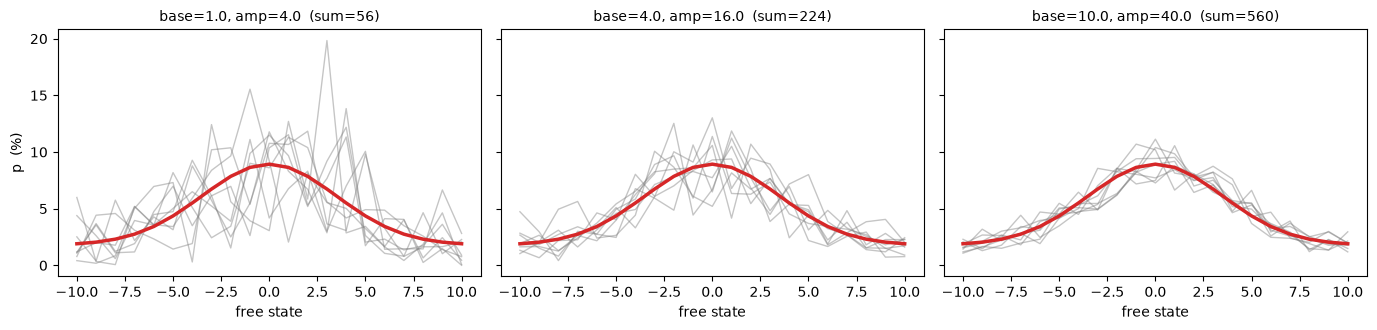

In [6]:
settings = [(1.0, 4.0), (4.0, 16.0), (10.0, 40.0)]
fig, axes = plt.subplots(1, len(settings), figsize=(14, 3.4), sharey=True)

for ax, (base, amp) in zip(axes, settings):
    conc = initial_state_concentration(S, "Markov", base=base, amp=amp)
    for d in rng.dirichlet(conc, n_draws):
        ax.plot(states, 100 * d, c="grey", alpha=0.45, lw=1)
    ax.plot(states, 100 * conc / conc.sum(), c="C3", lw=2.5)
    ax.set_title(f"base={base}, amp={amp}  (sum={conc.sum():.0f})", fontsize=10)
    ax.set_xlabel("free state")

axes[0].set_ylabel("p  (%)")
plt.tight_layout()

## In the full 51-state space

`p_0` is padded with `response_width` zeros on each side before becoming `phi_0`. For Quantum
`phi_0 = sqrt(p_0)`, since it is an amplitude rather than a probability. Note where the Quantum
boundary mass sits relative to the response zones.

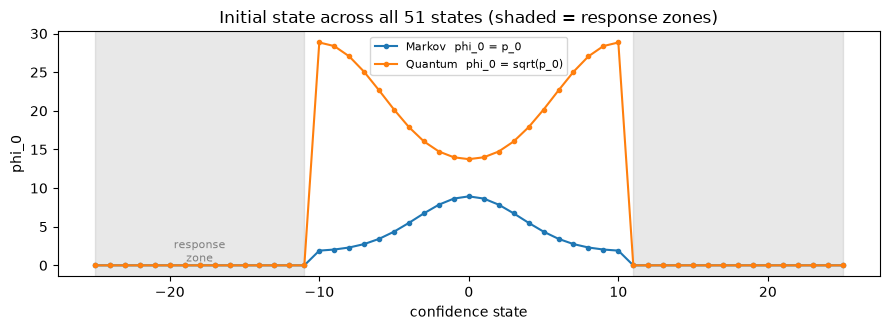

In [7]:
full = np.arange(N_STATES) - (N_STATES - 1) / 2
pad = (RESPONSE_WIDTH, RESPONSE_WIDTH)

p_markov = np.pad(conc_markov / conc_markov.sum(), pad)
p_quantum = np.pad(conc_quantum / conc_quantum.sum(), pad)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(full, 100 * p_markov, "o-", ms=3, label="Markov  phi_0 = p_0")
ax.plot(full, 100 * np.sqrt(p_quantum), "o-", ms=3, label="Quantum  phi_0 = sqrt(p_0)")
ax.axvspan(full[0], full[RESPONSE_WIDTH - 1], color="grey", alpha=0.18)
ax.axvspan(full[-RESPONSE_WIDTH], full[-1], color="grey", alpha=0.18)
ax.text(full[RESPONSE_WIDTH // 2], 0.5, "response\nzone", ha="center", fontsize=8, c="grey")
ax.set_xlabel("confidence state")
ax.set_ylabel("phi_0")
ax.set_title("Initial state across all 51 states (shaded = response zones)")
ax.legend(fontsize=8)
plt.tight_layout()